Republicans vs. Democrats: How has public opinion changed in the last year?

The research question I chose is: which party looks more likely to win the 2026 midterm elections and secure a majority in the U.S. Congress? 

The history of U.S. elections has shown that the number one indicator of a midterm victory is the generic congressional ballot ("Why the Generic Ballot Test?"). These surveys ask some version of the same basic question, “if the upcoming midterm elections were today, which party are you likely to vote for?” As such, I chose an aggregation of generic ballot polls collected by reputable election polling blog, natesilver.net., which was started by the same Nate Silver of the well-known FiveThirtyEight blog (Silver and McKown-Dawson).  The individual polls are collected by a variety of agencies, including some of the most well-respected polling organizations in the country. The Washington Post, New York Times, Gallup, Quinnipiac, and Emerson polls, to give a few examples.  

The data includes a number of categories of data, but I will be focusing on seven in particular. These are the pollster, startdate, enddate, adjusted_dem, adjusted_rep, adjusted_net, and poll_id columns. The dataset includes both an adjusted and unadjusted figure for the approval numbers, the adjusted figure having been calculated by folks at the Nate Silver website. I chose the adjusted numbers because they took into account a number of factors I found important. These included the accuracy of the source, the sample size of the poll, and how recently it had been conducted. 

My overall analytical approach was to do two things. The first was to take a look at how the approval ratings were trending over the last year. The second was to take a more detailed snapshot of where the approval ratings stood today, just under eight months before the general midterm elections. As a summary I chose to compare the net ratings for Democrats and Republicans in the oldest polls in my sample against the newest.  

The key findings from my analysis show that not only is the Democratic party leading in the polls currently, but this is a continuation of a trend that began following President Trump’s second inauguration. The lead is quite clear across the selection of polls, and the trend toward rising Democratic approval is also quite clear in the data. It should be noted that part of this trend is recovering from a dip in popularity the Democrats suffered after losing the 2024 election (Johansen). 

Since polls only provide a snapshot in time of public opinion, it is vital that the polling agencies continue to conduct scientifically rigorous surveys leading all the way up to the election in November. As we saw in the 2016 election, undecided voters may not make up their minds until the last couple of weeks before a vote. In the shorter term, it will be interesting to see how public opinion responds to the recently started war in Iran, and the rising prices that will almost certainly follow. Military actions can have significant public opinion consequences, both positive and negative. Rising prices are always bad for incumbents, echoing political strategist James Carville’s old phrase, “it’s the economy, stupid.” 

In conclusion, the data gives a preliminary answer to who will win the midterms, but it is much too early in the election cycle to decisively pick a victor. Public opinion can vary wildly between now and November, and pollsters still have plenty of work ahead trying to predict the results. Ultimaltely, elections are won by votes, not by polls. 


Works Cited 

Johansen, Ben. “Democrats Tumble in New Poll.” POLITICO, Politico, 26 July 2025, www.politico.com/news/2025/07/26/democrats-approval-rating-poll-00478141.

Silver, Nate, and Eli McKown-Dawson. “Generic Congressional Ballot: Latest Polls | Silver Bulletin.” Natesilver.net, Silver Bulletin, 30 Jan. 2026, www.natesilver.net/p/generic-ballot-average-2026-nate-silver-bulletin-congress-polls.

“Why the Generic Ballot Test?” Pew Research Center, Oct. 2002, www.pewresearch.org/politics/2002/10/01/why-the-generic-ballot-test/.




Step 1: Load packages and data. 

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#selecting only the columns needed for analysis
columns = ['pollster','startdate','enddate','adjusted_dem','adjusted_rep','adjusted_net','poll_id']
df = pd.read_csv('polls.csv', usecols=columns) 
df.head()
#df.shape
#df.info()

,pollster,startdate,enddate,adjusted_dem,adjusted_rep,adjusted_net,poll_id
0,Emerson College,2/21/2026,2/22/2026,51.45721,43.22903,8.228180,901139
1,Hart Research Associates/Public Opinion Strate...,2/27/2026,3/3/2026,48.59388,42.79200,5.801880,901183
2,Cygnal,2/24/2026,2/26/2026,47.66132,42.51203,5.149288,901177
3,Echelon Insights,2/19/2026,2/23/2026,49.32269,43.64447,5.678219,901127
4,TIPP Insights,1/27/2026,1/29/2026,45.67573,42.13840,3.537331,901111


Step 2: Creating a scatterplot to show trend of Democratic Party approval. 

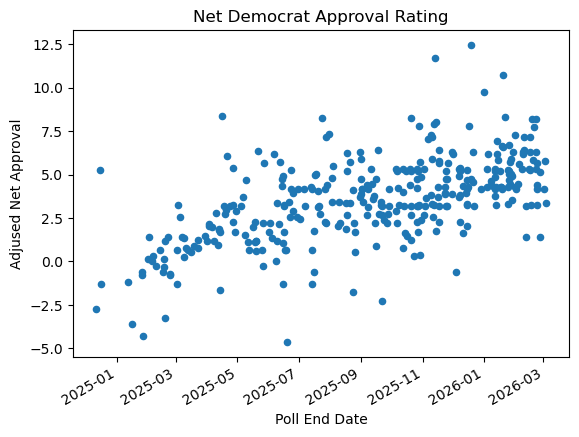

In [121]:
#convert date columns into correct datetime format
df['startdate'] = pd.to_datetime(df['startdate'], format='mixed', dayfirst=False)
df['enddate'] = pd.to_datetime(df['enddate'], format='mixed', dayfirst=False)

df.head()

#create new date sorted dataframe to plot. 

# df_sorted = df.sort_values(by='enddate')
# #df_sorted.tail()

df_sorted.plot.scatter(x='enddate', y='adjusted_net', title='Net Democrat Approval Rating')
plt.xlabel('Poll End Date')
plt.ylabel('Adjused Net Approval')
plt.gcf().autofmt_xdate()
plt.show()

Step 3: Create a snapshot of where Democrats and Republicans stand currently, using data from February and March 2026. 

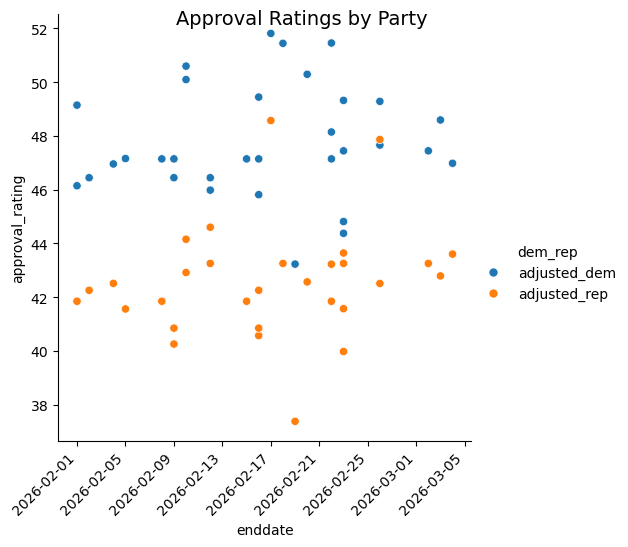

In [131]:
#creat filtered data frame using the appropriate date range
start_date = '2026-02-01'
end_date = '2026-03-15'
df_current = df[df['enddate'].between(start_date, end_date)]
# df_current.info()

#combine adjusted_dem and adjusted_rep using melt so they can be plotted on the same graph. 
df_melted = df_current.melt(id_vars=['enddate'], 
                     value_vars=['adjusted_dem', 'adjusted_rep'], 
                     var_name='dem_rep', 
                     value_name='approval_rating')

#print(df_melted)

#plot democratic and republican data on same graph to make comparison. 

sns.relplot(data=df_melted, 
            x="enddate", 
            y="approval_rating", 
            hue="dem_rep", 
            kind="scatter")

plt.suptitle('Approval Ratings by Party', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

Step 4: Create Summary Table. Use the median of the oldest and newest 25 polls to create a snapshot of each time period. 

In [123]:
#Calculate median approval ratings for both parties. Earliest 25 polls, latest 25. 

#create data frames of 25 oldest and newest records. 
df_oldest = df_sorted.head(25)
#df_oldest.head(25)
df_newest= df_sorted.tail(25)
#df_newest.head(25)

#determine the median for each combination of age and party. 
rep_old = df_oldest['adjusted_rep'].median()
rep_new = df_newest['adjusted_rep'].median()
dem_old = df_oldest['adjusted_dem'].median()
dem_new = df_newest['adjusted_dem'].median()
dem_net_change = dem_new-rep_new

# Define column names and fill with data. 
data = {
    'Median of Oldest 25': [dem_old, rep_old, dem_old-rep_old],    
    'Median of Latest 25': [dem_new, rep_new, dem_net_change],    
    'Net Change': [dem_new-dem_old,rep_new-rep_old, (dem_new-dem_old)-(rep_new-rep_old)]
}

# Create dataframe for table and name rows. 
df_table = pd.DataFrame(data, index=['Democrats', 'Republicans', 'Net Democrats'])

print('               Table of Oldest and Newest Approval Ratings') 
print()
print(df_table)



               Table of Oldest and Newest Approval Ratings

               Median of Oldest 25  Median of Latest 25  Net Change
Democrats                 44.44584             47.44584     3.00000
Republicans               44.82149             42.79200    -2.02949
Net Democrats             -0.37565              4.65384     5.02949
